In [16]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

(60000, 28, 28)
(10000, 28, 28)


Text(0.5, 1.0, '0')

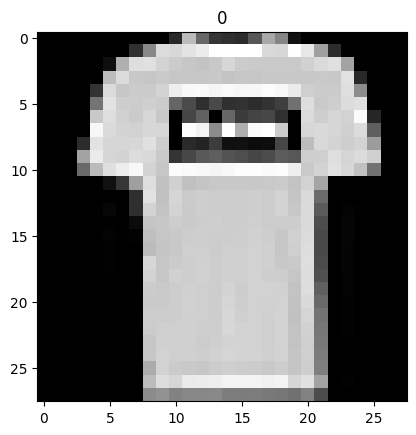

In [17]:
# 데이터 불러오기
(x_train, y_train),(x_test, y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(X_test.shape)

import matplotlib.pyplot as plt
plt.imshow(x_train[1],cmap="gray")
plt.title(y_train[1])

In [18]:
import sys
for x in x_train[0]:
    for i in x:
        sys.stdout.write("%-3s" % i) # 첫번째행 오른쪽 3자리수 맞추어서 출력
    sys.stdout.write('\n')

0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  
0  0  0  0  0  0  0  0  0  0  0  0  1  0  0  13 73 0  0  1  4  0  0  0  0  1  1  0  
0  0  0  0  0  0  0  0  0  0  0  0  3  0  36 13612762 54 0  0  0  1  3  4  0  0  3  
0  0  0  0  0  0  0  0  0  0  0  0  6  0  10220417613414412323 0  0  0  0  12 10 0  
0  0  0  0  0  0  0  0  0  0  0  0  0  0  15523620717810715616110964 23 77 13072 15 
0  0  0  0  0  0  0  0  0  0  0  1  0  69 20722321821621616312712112214614188 17266 
0  0  0  0  0  0  0  0  0  1  1  1  0  2002322322332292232232152131641271231962290  
0  0  0  0  0  0  0  0  0  0  0  0  0  1832252162232282352272242222242212232451730  
0  0  0  0  0  0  0  0  0  0  0  0  0  1932282182131981802122102112132232202432020  
0  0  0  0  0  0  0  0  0  1  3  0  12 21922021221819216922720821

In [19]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [20]:
# 정규화
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# CNN 입력 형태
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

# CNN 모델링

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.3),
    Dense(10,activation="softmax")
])

model.summary()

# 컴파일
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# 평가
loss, accuracy = model.evaluate(x_test,y_test)
print("정확도", accuracy)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8392 - loss: 0.4531 - val_accuracy: 0.8882 - val_loss: 0.3075
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8889 - loss: 0.3087 - val_accuracy: 0.9003 - val_loss: 0.2750
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9031 - loss: 0.2671 - val_accuracy: 0.9033 - val_loss: 0.2696
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9114 - loss: 0.2395 - val_accuracy: 0.9083 - val_loss: 0.2541
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9203 - loss: 0.2165 - val_accuracy: 0.9093 - val_loss: 0.2498
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9260 - loss: 0.1967 - val_accuracy: 0.9130 - val_loss: 0.2493
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9333 - loss: 0.1786 - val_accuracy: 0.9153 - val_loss: 0.2491
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9387 - loss: 0.1649 - 

In [22]:
model.save("Fashion_mnist_cnn.keras")

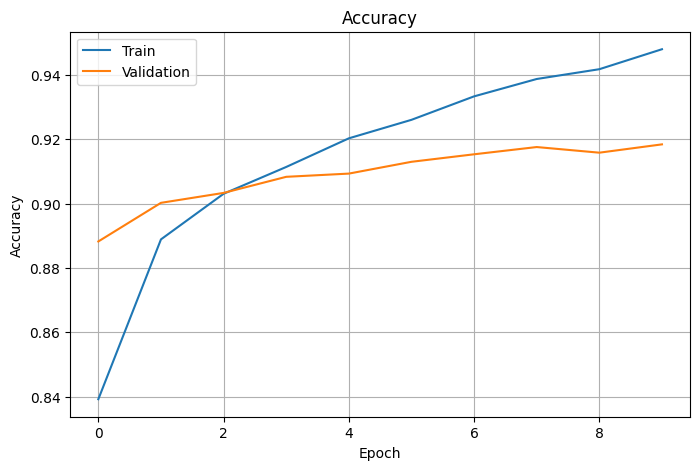

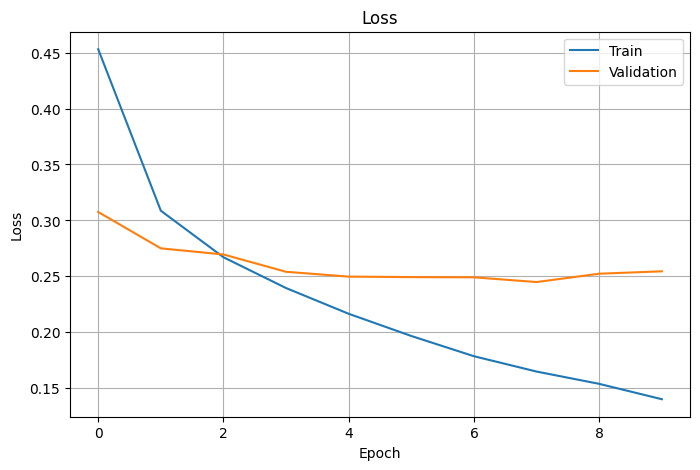

In [23]:
#------------------------------------
# Accuracy 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

#------------------------------------
# Loss 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# 파라미터 조정

# Conv2D 필터 수: 32 → 64 → 128
# 커널 크기: 3x3 vs 5x5
# MaxPooling2D 제거 또는 추가
# Dropout(0.3) 추가 전후 비교
# Epoch: 5, 10, 20
# Optimizer: Adam vs SGD
# Batch Size: 16, 32, 64